<a href="https://www.kaggle.com/code/nithinreddy600/rq3ev-charging-behavior-analysis-and-financialrisk?scriptVersionId=316438384" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# RQ3: Feature-Block Ablation Study

This Kaggle notebook tests whether adding charging-behavior and product-performance features improves default-risk prediction.

**Outputs saved to `/kaggle/working/rq3_feature_block_ablation/`:**
- `RQ3_feature_block_ablation_table.csv`
- `RQ3_feature_block_ablation_figure.pdf`

**Research question:** Does adding charging-behavior and product-performance features improve default-risk prediction beyond demographic and financial variables alone?

## Run this cell to generate the actual answer, CSV table, and PDF figure

The notebook automatically searches for the dataset file inside `/kaggle/input`. If it cannot find it, set `DATASET_PATH` manually in the code cell.

Output folder: /kaggle/working/rq3_feature_block_ablation
Loading dataset from: /kaggle/input/datasets/nithinreddy600/ev-charging-behavior-analysis-and-financial-risk/EV charging behavior analysis and financial risk.csv
Raw dataset shape: 18,941 rows × 18 columns
Cleaned dataset shape: (18941, 18)

Columns:
['User_ID', 'Age', 'City_Tier', 'EV_Type', 'Battery_Capacity_kWh', 'Charging_Sessions_Per_Month', 'Avg_Charge_Cost', 'Distance_Travelled_Per_Month', 'Income_Level', 'Loan_Taken', 'Missed_Payments_Last_6M', 'Tenure_Months', 'Charging_Location_Type', 'App_Usage_Score', 'Charger_Working_Status', 'Charging_Time_Minutes', 'High_Default_Risk', 'Charging_Efficiency_Index']

Missing values:


,missing_count
User_ID,0
Age,0
City_Tier,0
EV_Type,0
Battery_Capacity_kWh,0
Charging_Sessions_Per_Month,0
Avg_Charge_Cost,0
Distance_Travelled_Per_Month,0
Income_Level,0
Loan_Taken,0


,Feature_Block_Model,Variables_Included,Accuracy,F1_score,ROC_AUC,Delta_ROC_AUC_vs_Demographics
0,Demographics only,"Age, City_Tier, Income_Level",0.6353,0.5753,0.6522,0.0000
1,Financial behavior only,"Income_Level, Loan_Taken, Missed_Payments_Last...",0.7271,0.6884,0.7904,0.1381
2,Charging behavior only,"EV_Type, Battery_Capacity_kWh, Charging_Sessio...",0.7627,0.7177,0.8470,0.1947
3,Financial + charging behavior,"Income_Level, Loan_Taken, Missed_Payments_Last...",0.9931,0.9923,0.9999,0.3476
4,Full feature model,"Age, City_Tier, EV_Type, Battery_Capacity_kWh,...",0.9939,0.9932,0.9999,0.3477


Saved table: /kaggle/working/rq3_feature_block_ablation/RQ3_feature_block_ablation_table.csv
Actual answer for RQ3: The best feature block is 'Full feature model' with ROC-AUC = 0.9999. The improvement over demographics only is 0.3477.
Saved figure: /kaggle/working/rq3_feature_block_ablation/RQ3_feature_block_ablation_figure.pdf


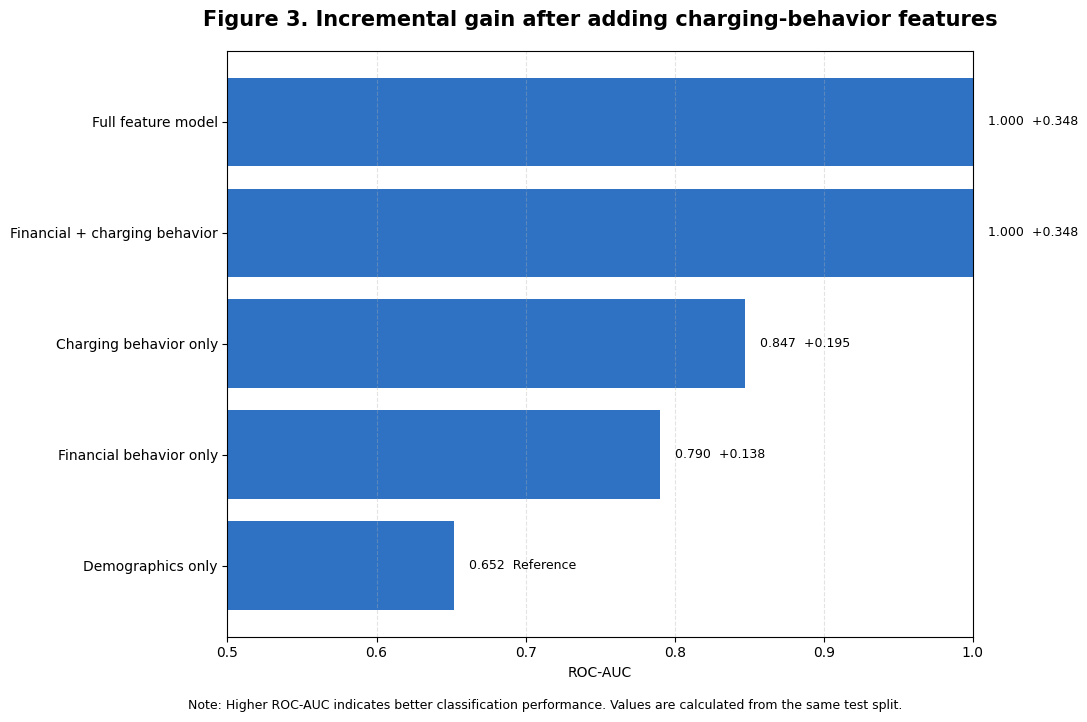

In [1]:

# ============================================================
# Common setup: imports, paths, loading, cleaning, preprocessing
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42

# Change this manually only if Kaggle cannot auto-detect your file.
# Example:
# DATASET_PATH = "/kaggle/input/ev-charging-behavior-analysis-and-financial-risk/your_file.csv"
DATASET_PATH = None

def file_has_expected_columns(path):
    """
    Checks whether a candidate file looks like the raw EV dataset rather than
    an output table generated by one of the notebooks.
    """
    try:
        if path.lower().endswith(".csv"):
            cols = pd.read_csv(path, nrows=0).columns.astype(str).str.strip().tolist()
        elif path.lower().endswith((".xlsx", ".xls")):
            cols = pd.read_excel(path, nrows=0).columns.astype(str).str.strip().tolist()
        else:
            return False
    except Exception:
        return False

    required = {"High_Default_Risk", "Charging_Efficiency_Index"}
    return required.issubset(set(cols)) and len(cols) >= 10

def find_dataset_file():
    """
    Finds the raw CSV or Excel dataset file automatically.
    Works in Kaggle by searching /kaggle/input first.
    Also avoids accidentally selecting CSV output tables generated by the notebooks.
    """
    if DATASET_PATH is not None and os.path.exists(DATASET_PATH):
        return DATASET_PATH

    roots = ["/kaggle/input", ".", "/mnt/data"]
    extensions = (".csv", ".xlsx", ".xls")
    candidates = []

    for root in roots:
        if not os.path.exists(root):
            continue
        for dirpath, _, filenames in os.walk(root):
            # Skip common output folders when running locally
            if any(part.startswith("rq") and "output" in part for part in dirpath.lower().split(os.sep)):
                continue
            for filename in filenames:
                lower = filename.lower()
                if lower.endswith(extensions):
                    candidates.append(os.path.join(dirpath, filename))

    if not candidates:
        raise FileNotFoundError(
            "No CSV/XLS/XLSX file found. Add the Kaggle dataset to the notebook "
            "or set DATASET_PATH manually."
        )

    # First priority: files that actually contain the required raw dataset columns.
    valid_raw_files = [path for path in candidates if file_has_expected_columns(path)]
    if valid_raw_files:
        keywords = ["ev", "charging", "financial", "risk", "behavior"]
        preferred = [
            path for path in valid_raw_files
            if any(word in os.path.basename(path).lower() for word in keywords)
        ]
        return sorted(preferred or valid_raw_files)[0]

    # Fallback: use filename keywords if header check cannot be completed.
    keywords = ["ev", "charging", "financial", "risk", "behavior"]
    preferred = [
        path for path in candidates
        if any(word in os.path.basename(path).lower() for word in keywords)
    ]

    selected = sorted(preferred or candidates)[0]
    return selected

def load_raw_dataset():
    path = find_dataset_file()
    print(f"Loading dataset from: {path}")

    if path.lower().endswith(".csv"):
        df = pd.read_csv(path)
    elif path.lower().endswith((".xlsx", ".xls")):
        df = pd.read_excel(path)
    else:
        raise ValueError("Unsupported file type. Use CSV, XLSX, or XLS.")

    print(f"Raw dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
    return df

def clean_dataset(df):
    """
    Basic cleaning for this EV charging dataset:
    - strips column names and string values
    - removes duplicate rows
    - converts known numeric columns
    - converts impossible negative values into missing values
    - standardizes binary columns where needed
    """
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    df = df.drop_duplicates()

    # Strip text columns
    for col in df.select_dtypes(include=["object"]).columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({"nan": np.nan, "None": np.nan, "": np.nan})

    # Standardize binary columns if they came in as text before numeric conversion
    binary_maps = {
        "yes": 1, "y": 1, "true": 1, "high": 1, "risk": 1, "default": 1, "1": 1,
        "no": 0, "n": 0, "false": 0, "low": 0, "non-risk": 0, "non risk": 0, "0": 0
    }
    for col in ["Loan_Taken", "High_Default_Risk"]:
        if col in df.columns and df[col].dtype == "object":
            df[col] = df[col].astype(str).str.lower().map(binary_maps)

    known_numeric = [
        "User_ID", "Age", "Battery_Capacity_kWh", "Charging_Sessions_Per_Month",
        "Avg_Charge_Cost", "Distance_Travelled_Per_Month", "Loan_Taken",
        "Missed_Payments_Last_6M", "Tenure_Months", "App_Usage_Score",
        "Charging_Time_Minutes", "High_Default_Risk", "Charging_Efficiency_Index"
    ]
    for col in known_numeric:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Treat impossible negative values as missing
    non_negative_cols = [
        "Age", "Battery_Capacity_kWh", "Charging_Sessions_Per_Month",
        "Avg_Charge_Cost", "Distance_Travelled_Per_Month",
        "Missed_Payments_Last_6M", "Tenure_Months", "App_Usage_Score",
        "Charging_Time_Minutes", "Charging_Efficiency_Index"
    ]
    for col in non_negative_cols:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan

    # Keep app score in a practical range if the column exists
    if "App_Usage_Score" in df.columns:
        df.loc[(df["App_Usage_Score"] < 0) | (df["App_Usage_Score"] > 10), "App_Usage_Score"] = np.nan

    return df

def make_output_dir(name):
    output_dir = os.path.join("/kaggle/working" if os.path.exists("/kaggle/working") else ".", name)
    os.makedirs(output_dir, exist_ok=True)
    print(f"Output folder: {output_dir}")
    return output_dir

def split_features_target(df, target_col, drop_cols=None):
    if drop_cols is None:
        drop_cols = []
    if target_col not in df.columns:
        raise KeyError(f"Target column '{target_col}' not found. Available columns: {list(df.columns)}")

    data = df.dropna(subset=[target_col]).copy()

    # Force target to integer binary if classification
    if target_col == "High_Default_Risk":
        data = data[data[target_col].isin([0, 1])].copy()
        data[target_col] = data[target_col].astype(int)

    y = data[target_col]
    X = data.drop(columns=[target_col] + [c for c in drop_cols if c in data.columns])
    return X, y, data

def get_feature_types(X):
    categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    numeric_cols = [c for c in X.columns if c not in categorical_cols]
    return numeric_cols, categorical_cols

def make_preprocessor(X, scale_numeric=True):
    numeric_cols, categorical_cols = get_feature_types(X)

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=numeric_steps)

    try:
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ])
    except TypeError:
        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=False))
        ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )
    return preprocessor, numeric_cols, categorical_cols

def get_transformed_feature_names(preprocessor, numeric_cols, categorical_cols):
    feature_names = list(numeric_cols)
    if categorical_cols:
        try:
            ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
            cat_names = list(ohe.get_feature_names_out(categorical_cols))
        except Exception:
            cat_names = []
            for col in categorical_cols:
                cat_names.append(col)
        feature_names.extend(cat_names)
    return feature_names

def save_table(df, output_dir, filename):
    path = os.path.join(output_dir, filename)
    df.to_csv(path, index=False)
    print(f"Saved table: {path}")
    return path

def save_figure(output_dir, filename):
    path = os.path.join(output_dir, filename)
    plt.savefig(path, format="pdf", bbox_inches="tight")
    print(f"Saved figure: {path}")
    return path

def style_plot(title, subtitle=None, xlabel=None, ylabel=None):
    plt.title(title, fontsize=15, fontweight="bold", pad=18)
    if subtitle:
        plt.suptitle(subtitle, fontsize=10, y=0.94, color="#3b4f6b")
    if xlabel:
        plt.xlabel(xlabel, fontsize=11)
    if ylabel:
        plt.ylabel(ylabel, fontsize=11)
    plt.grid(axis="y", linestyle="--", alpha=0.35)
    plt.gca().set_axisbelow(True)

def print_dataset_summary(df):
    print("Cleaned dataset shape:", df.shape)
    print("\nColumns:")
    print(list(df.columns))
    print("\nMissing values:")
    display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count").head(20))


# ============================================================
# RQ3: Does charging behavior improve default-risk prediction?
# ============================================================

from sklearn.ensemble import RandomForestClassifier

output_dir = make_output_dir("rq3_feature_block_ablation")

df_raw = load_raw_dataset()
df = clean_dataset(df_raw)
print_dataset_summary(df)

target_col = "High_Default_Risk"

feature_blocks = {
    "Demographics only": ["Age", "City_Tier", "Income_Level"],
    "Financial behavior only": ["Income_Level", "Loan_Taken", "Missed_Payments_Last_6M", "Tenure_Months", "Avg_Charge_Cost"],
    "Charging behavior only": [
        "EV_Type", "Battery_Capacity_kWh", "Charging_Sessions_Per_Month",
        "Distance_Travelled_Per_Month", "Charging_Location_Type",
        "Charger_Working_Status", "Charging_Time_Minutes",
        "Charging_Efficiency_Index", "App_Usage_Score"
    ],
    "Financial + charging behavior": [
        "Income_Level", "Loan_Taken", "Missed_Payments_Last_6M", "Tenure_Months",
        "Avg_Charge_Cost", "EV_Type", "Battery_Capacity_kWh",
        "Charging_Sessions_Per_Month", "Distance_Travelled_Per_Month",
        "Charging_Location_Type", "Charger_Working_Status",
        "Charging_Time_Minutes", "Charging_Efficiency_Index", "App_Usage_Score"
    ],
}

X_full, y, data = split_features_target(df, target_col, drop_cols=["User_ID"])
feature_blocks["Full feature model"] = list(X_full.columns)

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

rows = []

for block_name, features in feature_blocks.items():
    available_features = [c for c in features if c in X_full.columns]
    if not available_features:
        print(f"Skipping {block_name}: no listed features found.")
        continue

    X_train = X_train_full[available_features].copy()
    X_test = X_test_full[available_features].copy()

    preprocessor, _, _ = make_preprocessor(X_train, scale_numeric=False)
    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1]

    rows.append({
        "Feature_Block_Model": block_name,
        "Variables_Included": ", ".join(available_features),
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_score)
    })

results = pd.DataFrame(rows)

baseline_auc = results.loc[
    results["Feature_Block_Model"] == "Demographics only", "ROC_AUC"
].iloc[0]

results["Delta_ROC_AUC_vs_Demographics"] = results["ROC_AUC"] - baseline_auc

ordered_names = [
    "Demographics only",
    "Financial behavior only",
    "Charging behavior only",
    "Financial + charging behavior",
    "Full feature model"
]
results["Order"] = results["Feature_Block_Model"].apply(lambda x: ordered_names.index(x) if x in ordered_names else 99)
results = results.sort_values("Order").drop(columns="Order").reset_index(drop=True)

results_rounded = results.copy()
for col in ["Accuracy", "F1_score", "ROC_AUC", "Delta_ROC_AUC_vs_Demographics"]:
    results_rounded[col] = results_rounded[col].round(4)

display(results_rounded)
save_table(results_rounded, output_dir, "RQ3_feature_block_ablation_table.csv")

best = results_rounded.sort_values("ROC_AUC", ascending=False).iloc[0]
print(
    f"Actual answer for RQ3: The best feature block is '{best['Feature_Block_Model']}' "
    f"with ROC-AUC = {best['ROC_AUC']}. The improvement over demographics only is "
    f"{best['Delta_ROC_AUC_vs_Demographics']}."
)

# Figure 3: Horizontal bar chart of ROC-AUC by feature block
plot_df = results_rounded.sort_values("ROC_AUC", ascending=True)

plt.figure(figsize=(11, 7))
bars = plt.barh(plot_df["Feature_Block_Model"], plot_df["ROC_AUC"], color="#2f72c4")

for bar, delta in zip(bars, plot_df["Delta_ROC_AUC_vs_Demographics"]):
    width = bar.get_width()
    label = "Reference" if abs(delta) < 1e-8 else f"+{delta:.3f}"
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.3f}  {label}", va="center", fontsize=9)

plt.xlim(0.50, 1.00)
plt.xlabel("ROC-AUC")
plt.title("Figure 3. Incremental gain after adding charging-behavior features", fontsize=15, fontweight="bold", pad=18)
plt.grid(axis="x", linestyle="--", alpha=0.35)
plt.figtext(
    0.5, -0.02,
    "Note: Higher ROC-AUC indicates better classification performance. Values are calculated from the same test split.",
    ha="center", fontsize=9
)
plt.tight_layout()

save_figure(output_dir, "RQ3_feature_block_ablation_figure.pdf")
plt.show()
